In [171]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/abdullahcetin/mirichoi0218insurance/insurance.csv


In [172]:
data=pd.read_csv('/kaggle/input/datasets/abdullahcetin/mirichoi0218insurance/insurance.csv')


In [173]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [174]:
data.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [175]:
data.shape

(1338, 7)

In [176]:
data.drop_duplicates()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [177]:
for var in data.columns:
    if(data[var].dtype=='object'):
        print(var,data[var].value_counts())

sex sex
male      676
female    662
Name: count, dtype: int64
smoker smoker
no     1064
yes     274
Name: count, dtype: int64
region region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


In [178]:
import matplotlib.pyplot as plt
import seaborn as sns

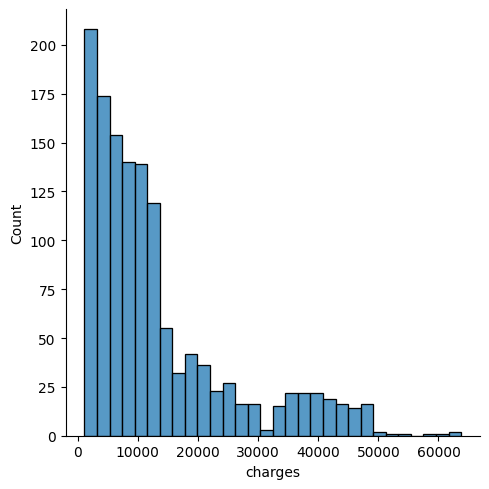

In [179]:
sns.displot(data['charges'])

In [180]:
num_col=['age','bmi','children']
cat_cols=['sex','smoker','region']

In [181]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocessing=ColumnTransformer(transformers=[
    ('num',StandardScaler(),num_col),
    ('cat',OneHotEncoder(),cat_cols)
])

In [182]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [183]:
x=data.drop(columns='charges')
y=np.log1p(data['charges'])

In [184]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model=Pipeline([
    ('pre',preprocessing),
    ('linearreg',LinearRegression())
])

In [185]:

model.fit(x_train,y_train)
pred1=model.predict(x_train)
print(r2_score(pred1,y_train))
print(mean_absolute_error(pred1,y_train))
print(mean_squared_error(pred1,y_train))

0.6794135633072459
0.2820457126747819
0.2014843378344216


In [186]:
pred2=model.predict(x_test)
print(r2_score(pred2,y_test))
print(mean_absolute_error(pred2,y_test))
print(mean_squared_error(pred2,y_test))

0.7437003665015411
0.26965057295320444
0.17550910855320753


In [187]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(
    model,
    x,
    y,
    cv=5,
    scoring='r2'
)
print("CV R² scores:", scores)
print("Mean R²:", scores.mean())

CV R² scores: [0.79832795 0.68668577 0.83126104 0.76834457 0.73434253]
Mean R²: 0.7637923732482437


Training advanced models

In [188]:
from sklearn.linear_model import Ridge,Lasso
from sklearn.ensemble import RandomForestRegressor
models={
    'rigde':Ridge(alpha=0.1),
    'lasso':Lasso(alpha=0.01),
    'rfr':RandomForestRegressor(n_estimators=100,random_state=42)
}
results={}
for name,reg in models.items():
    pipe=Pipeline([
        ('pre',preprocessing),
        ('re',reg)
    ])
    pipe.fit(x_train,y_train)
    pred1=pipe.predict(x_test)
    r2=r2_score(y_test,pred1)
    results[name]={'r2':r2*100}

results

{'rigde': {'r2': 80.47340936315263},
 'lasso': {'r2': 79.74818737700083},
 'rfr': {'r2': 84.64472581709948}}

comparing models

In [189]:
baseline={'linearregression':{'r2':scores.mean()*100}}
total_results={**baseline,**results}
compare=pd.DataFrame(total_results).T

In [190]:
compare

,r2
linearregression,76.379237
rigde,80.473409
lasso,79.748187
rfr,84.644726


conclusion: random forest regressor model given best results for the data